In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


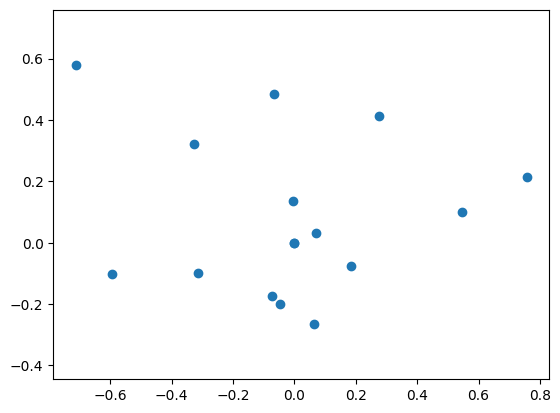

In [ ]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=16,  # 轨迹的控制点数量 16
)

# 偏移
# xs += 0.5
# ys += 0.5

# 噪声
xs[1:-1] += np.random.randn(len(xs) - 2) * 0.3
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.3

plt.scatter(xs, ys)
plt.axis('equal')
pass

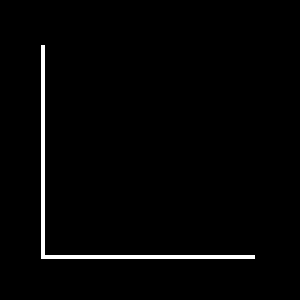

In [ ]:
# 可视化墙（白色区域为墙）

import math
from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    i1 = int(ti.math.atan2(y1, x1) / (ti.math.pi * 2) * 4 % 4)
    i2 = int(ti.math.atan2(y2, x2) / (ti.math.pi * 2) * 4 % 4)
    return ((i1 == 0) ^ (i2 == 0)) and ti.Vector([x2, y2]).norm() < 1

image = test_forbidden_function(
    is_forbidden,
    -0.2, 1.2, -0.2, 1.2, [300, 300],
    wall_normal=[0.02, 0.02]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
# 对称化
# 应该先执行不含对称化的计算，判断最优解很可能具有确定的对称性的情况下再加对称化约束

from utils import inverse_transformations, symmetrize_rotation

def symmetrize(xs, ys, rotations):  # 轨道4次旋转对称化
    xs_inv, ys_inv, rotations_inv = inverse_transformations(xs, ys, rotations)  # 求逆，得到沙发相对于房间的运动轨迹
    xs_inv_sym, ys_inv_sym = symmetrize_rotation(xs_inv, ys_inv, 4)  # 对称化
    xs_sym, ys_sym, rotations_sym = inverse_transformations(xs_inv_sym, ys_inv_sym, rotations_inv)  # 逆回去，得到房间相对于沙发的运动轨迹

    return xs_sym, ys_sym, rotations_sym

In [ ]:
# xs, ys, rotations = np.load('../trajectory/能让L形旋转一周的房间_0/sofa_800.npy')

In [6]:
sofa_w, sofa_h = 3.5, 3.5   # 求解域的尺寸

initial area = 10.899548530578613, initial loss = -10.899548530578613
iter 500 / 10000, maximal_area = 10.901324272155762, loss = -10.901324272155762
iter 1000 / 10000, maximal_area = 10.901744842529297, loss = -10.901744842529297
Adjusted mutation rate, mutation_sigma_pos = 0.033, mutation_sigma_rotation = 0.0
iter 1500 / 10000, maximal_area = 10.901838302612305, loss = -10.901838302612305
iter 2000 / 10000, maximal_area = 10.902352333068848, loss = -10.902352333068848
iter 2500 / 10000, maximal_area = 10.902632713317871, loss = -10.902632713317871
iter 3000 / 10000, maximal_area = 10.902679443359375, loss = -10.902679443359375
iter 3500 / 10000, maximal_area = 10.902772903442383, loss = -10.902772903442383
iter 4000 / 10000, maximal_area = 10.902819633483887, loss = -10.902819633483887
Adjusted mutation rate, mutation_sigma_pos = 0.0297, mutation_sigma_rotation = 0.0
iter 4500 / 10000, maximal_area = 10.90310001373291, loss = -10.90310001373291
iter 5000 / 10000, maximal_area = 10.90

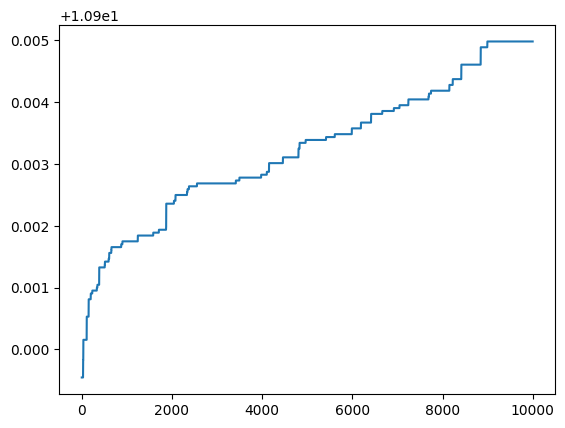

In [ ]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    ys,
    rotations,
    # initial_xs=zoom(xs, zoom=(2 * len(xs) - 1) / len(xs), order=1),  # 保持轨迹分辨率时注释掉这三行
    # initial_ys=zoom(ys, zoom=(2 * len(ys) - 1) / len(ys), order=1),
    # initial_rotations=zoom(rotations, zoom=(2 * len(rotations) - 1) / len(rotations), order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    iterations = 10000,  # 10000
    auto_divide_trajectory=True,
    mutation_sigma_pos = 0.03,  # 变异率
    mutation_sigma_rotation = 0,  # 变异率
    auto_adjust_mutation_rate=True,
    symmetrize_function=symmetrize,  # 轨迹4次旋转对称化函数
    trajectory_upsampling=21,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让L形旋转一周的房间_0/sofa_',
    save_image_start_id=0,  # 文件起始标号
    save_trajectory_path='../trajectory/能让L形旋转一周的房间_0/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

plt.plot(maximal_area_record)

In [13]:
len(xs)

241

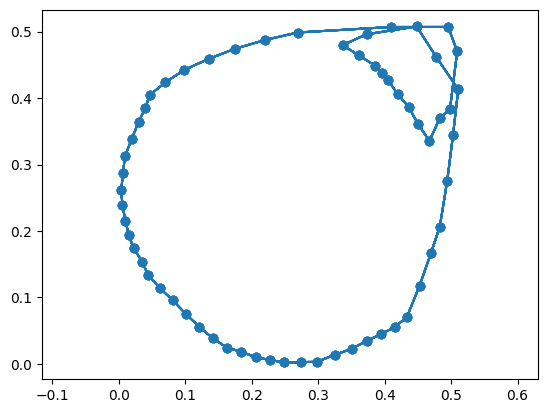

In [14]:
plt.plot(xs, ys, 'o-')
plt.axis('equal')
plt.show()

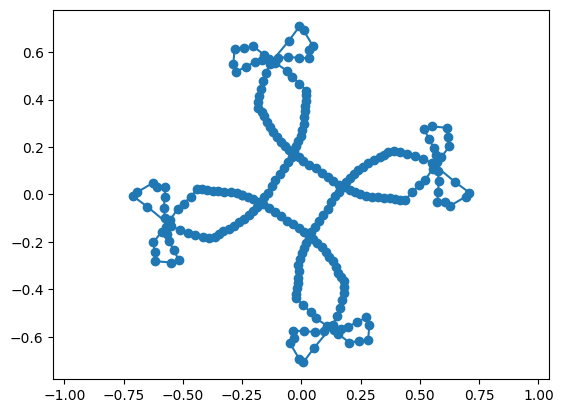

In [15]:
from utils import inverse_transformations

xs_inv, ys_inv, rotations_inv = inverse_transformations(xs, ys, rotations)
plt.plot(xs_inv, ys_inv, 'o-')
plt.axis('equal')
plt.show()

In [ ]:
from utils import get_area

best_score = get_area(is_forbidden, xs, ys, rotations, sofa_w, sofa_h, resolution=5000, trajectory_upsampling=200)  # 以很高的分辨率计算面积

area = sofa_w * sofa_h - best_score  # 房间面积
area_disk = np.pi / 2  # 外接圆面积
# area_circle = np.pi / 4
print(f'相对于外接圆：{area} / {area_disk} = {area / area_disk}')
# print(f'相对于圆环：{area} / {area_circle} = {area / area_circle}')

相对于外接圆：1.347747802734375 / 1.5707963267948966 = 0.8580028993856658


In [12]:
# 让电脑休眠

import os

os.system("rundll32.exe powrprof.dll,SetSuspendState 0,1,0")

0